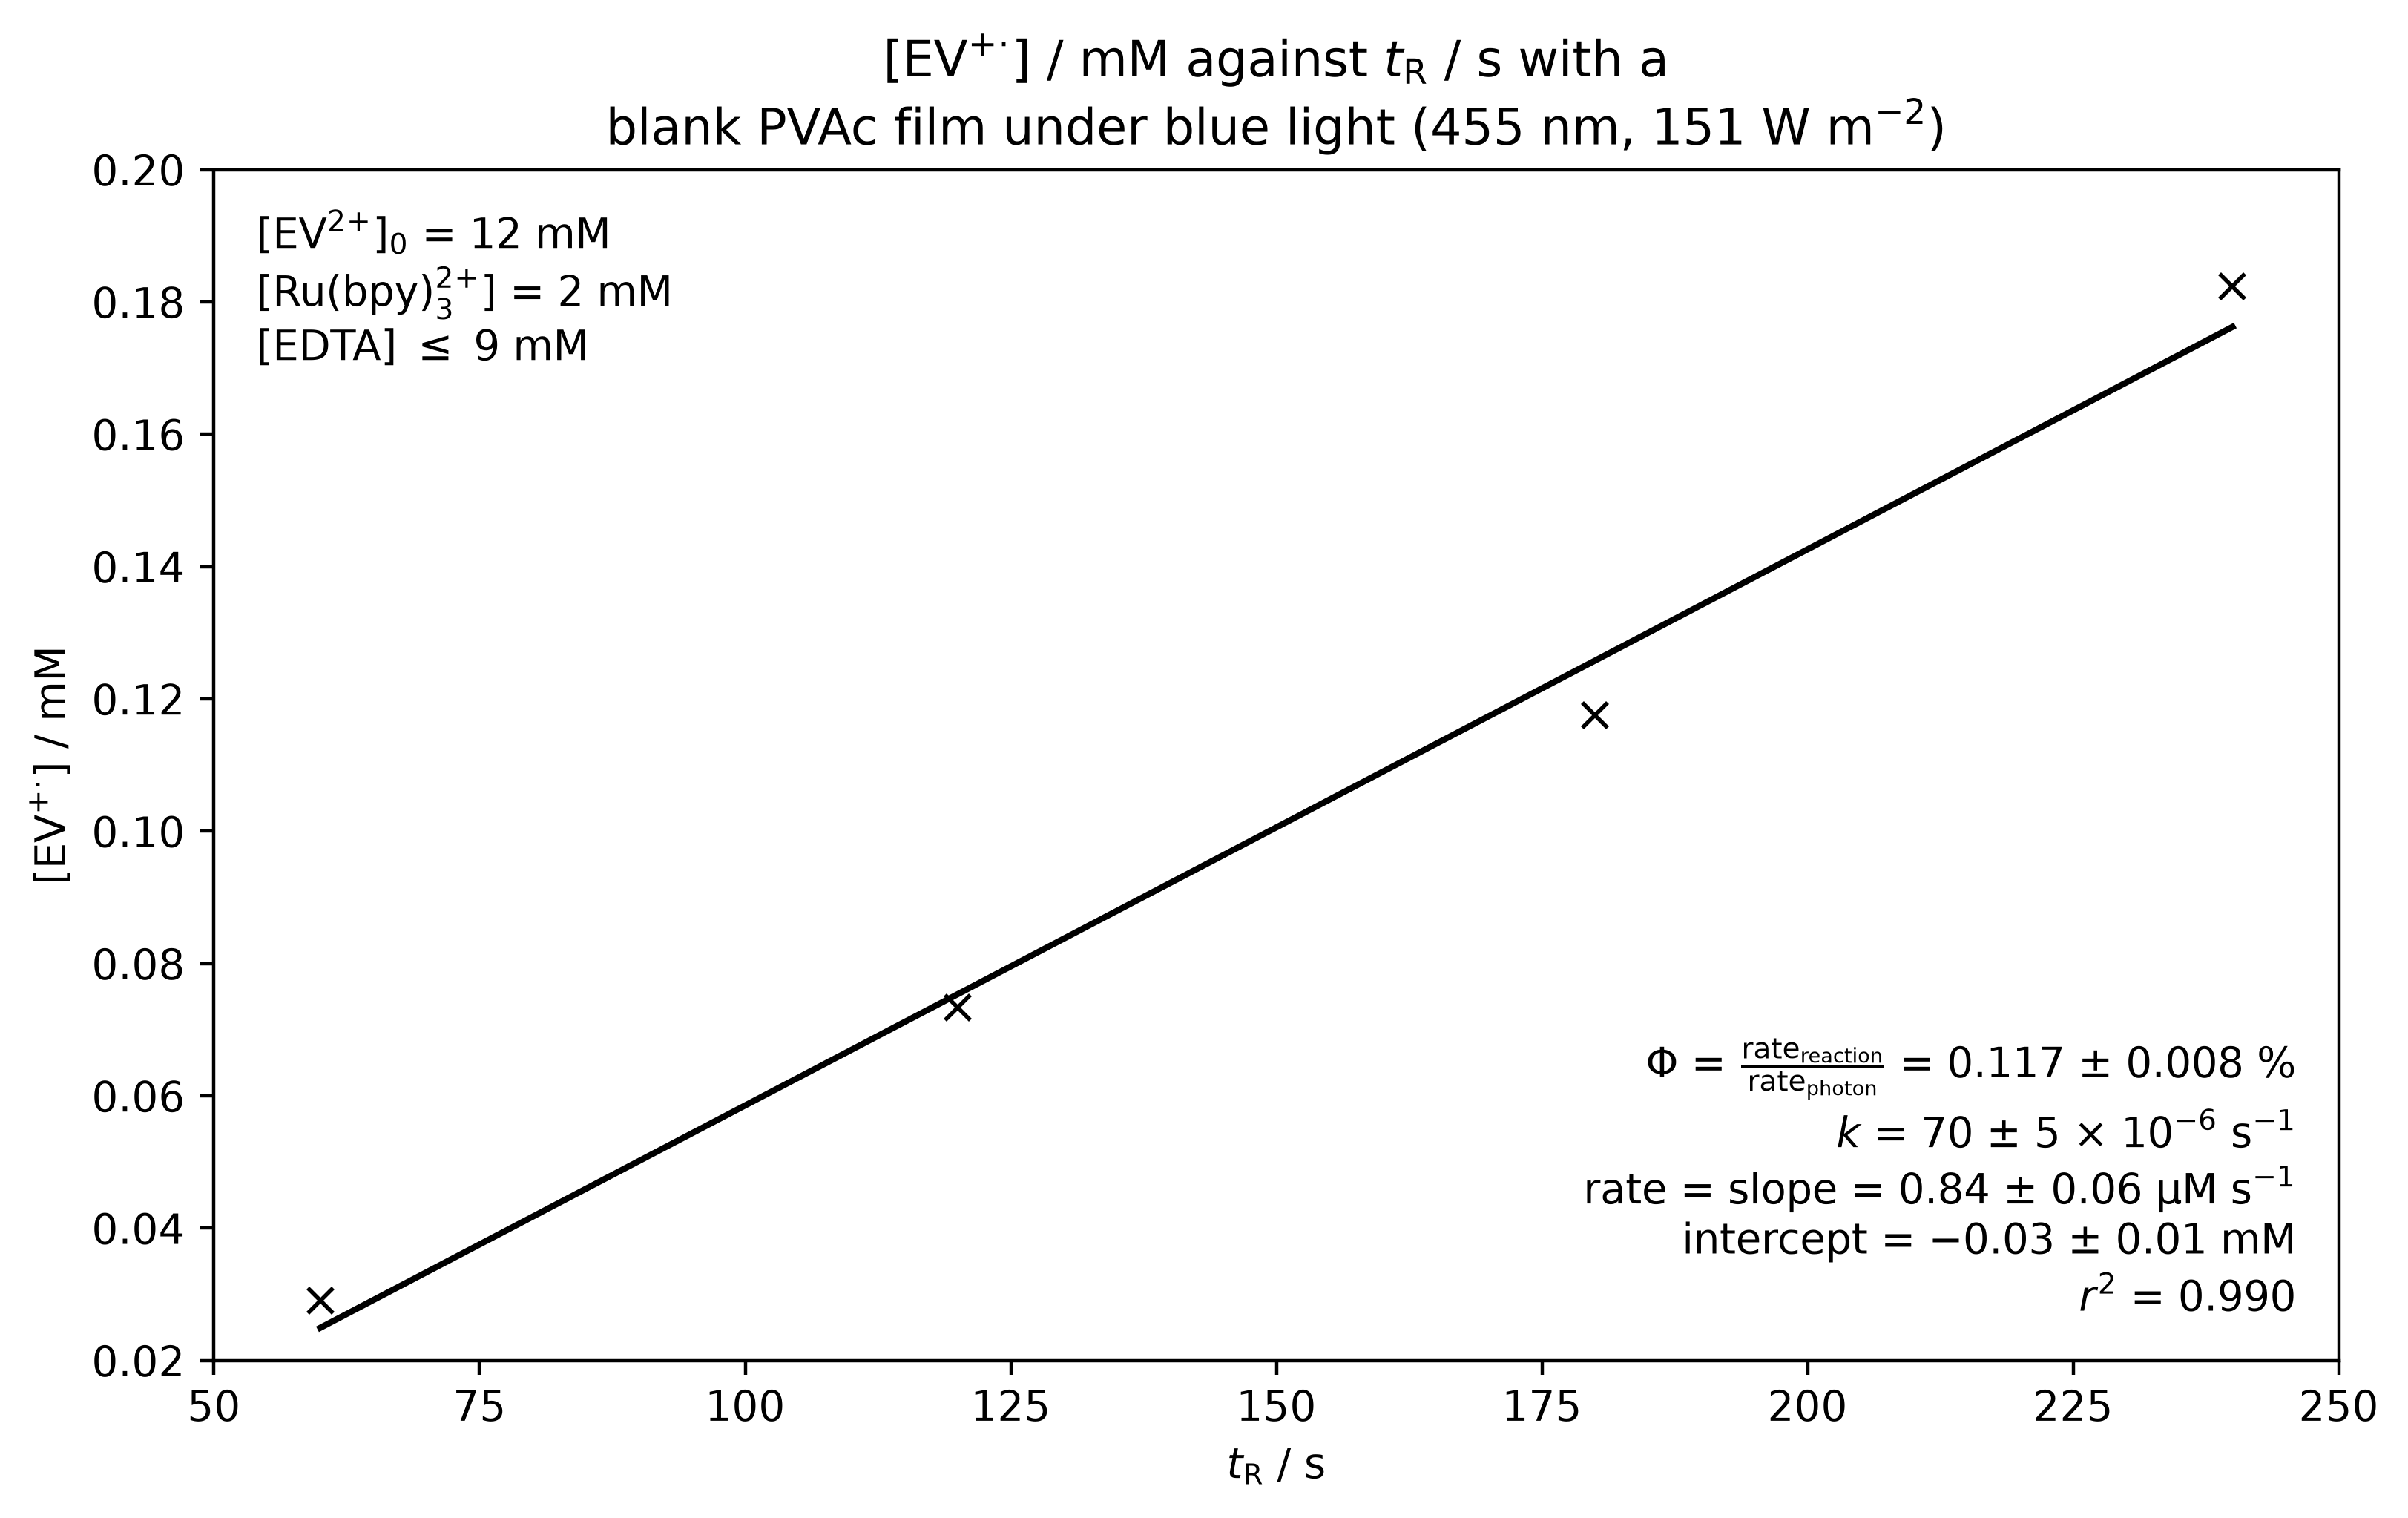

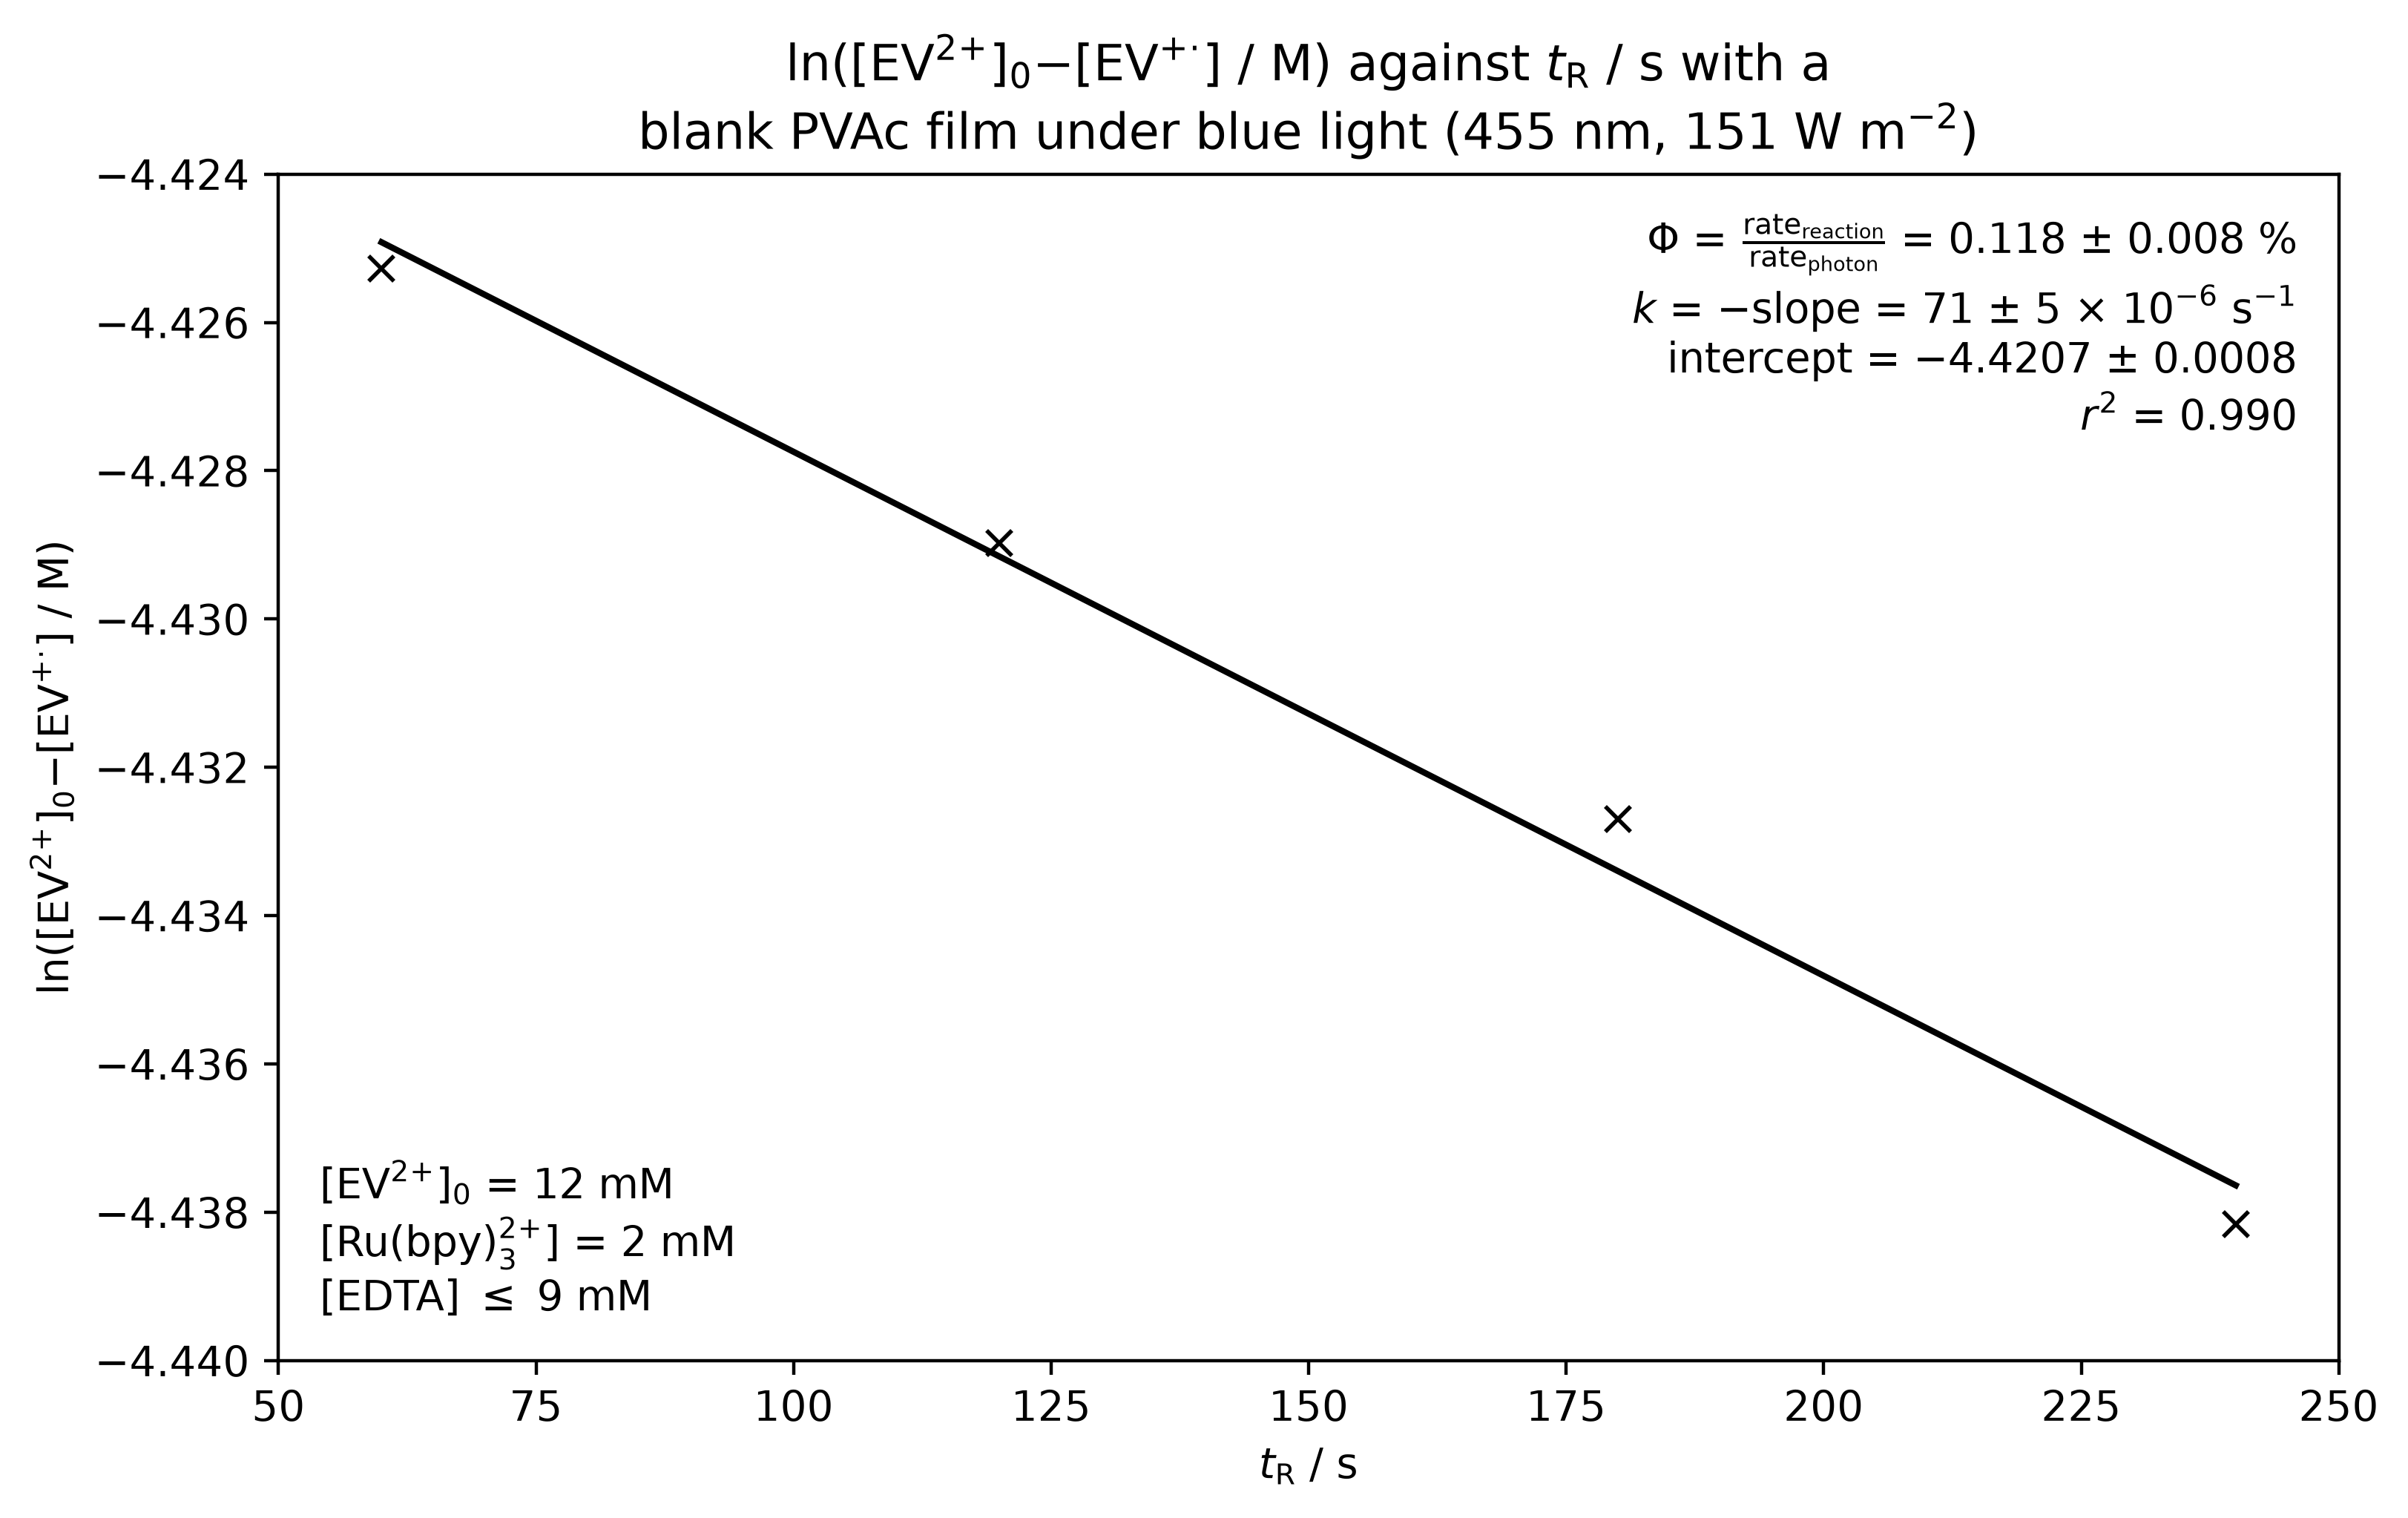

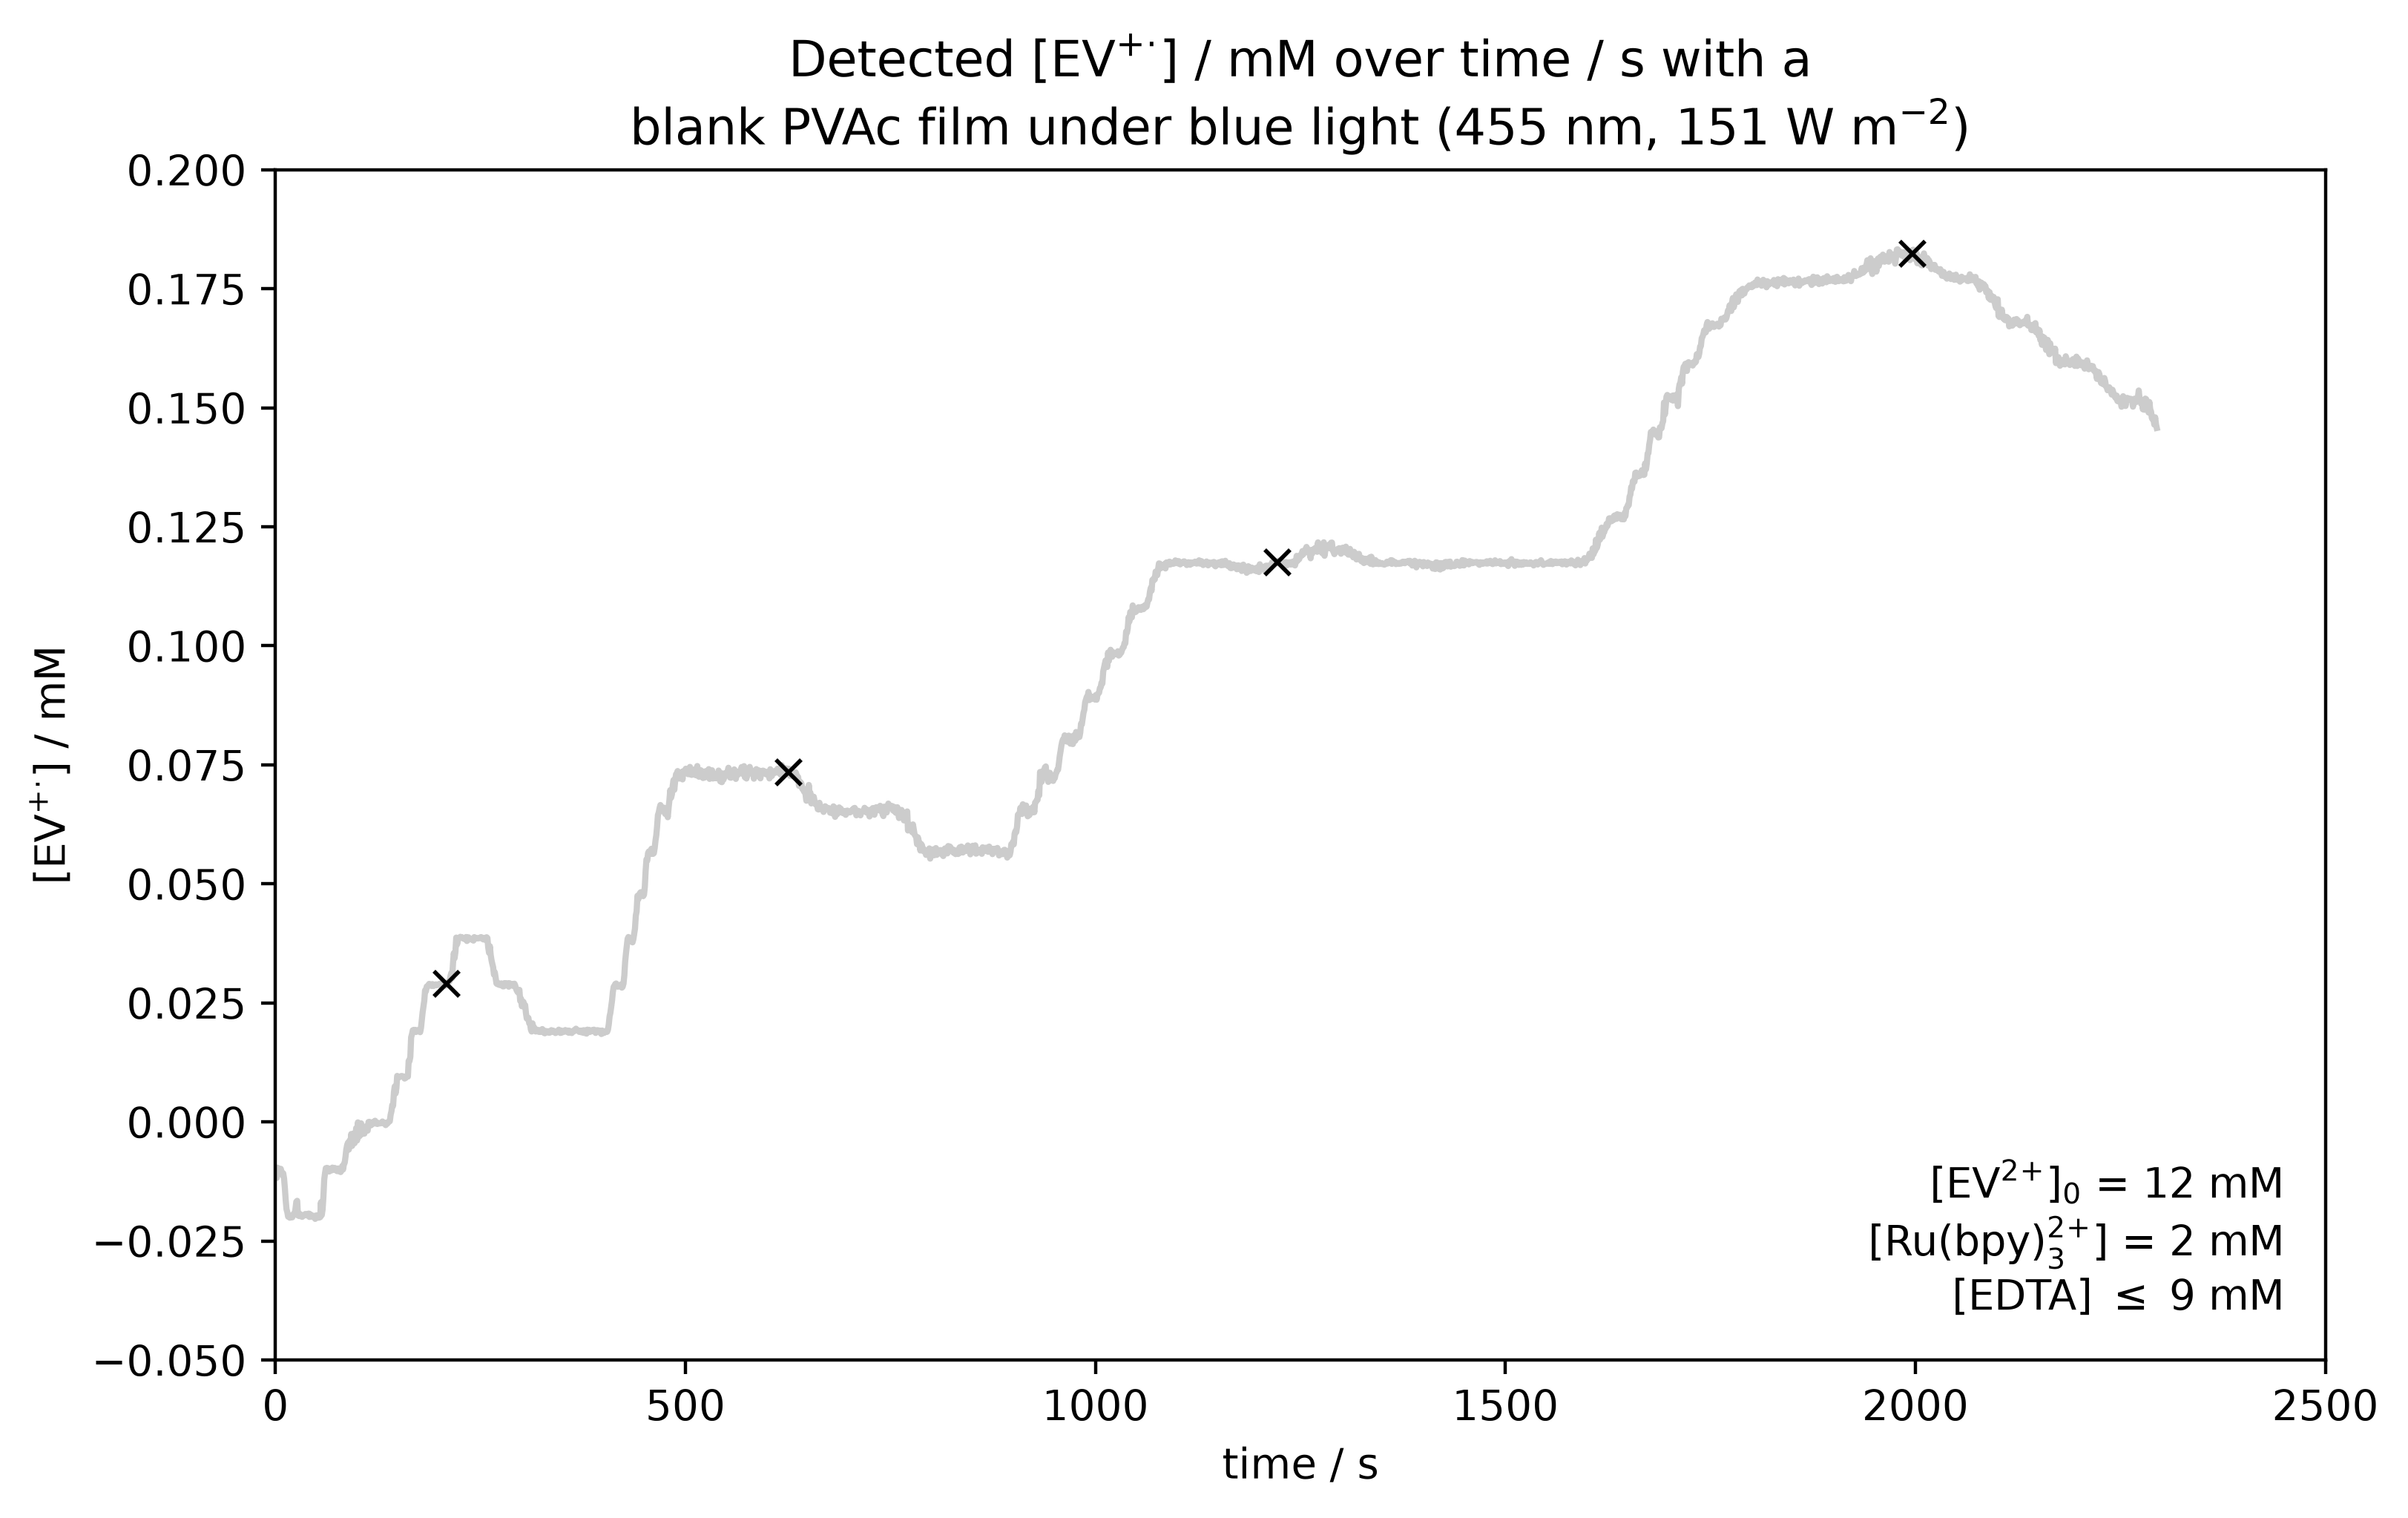

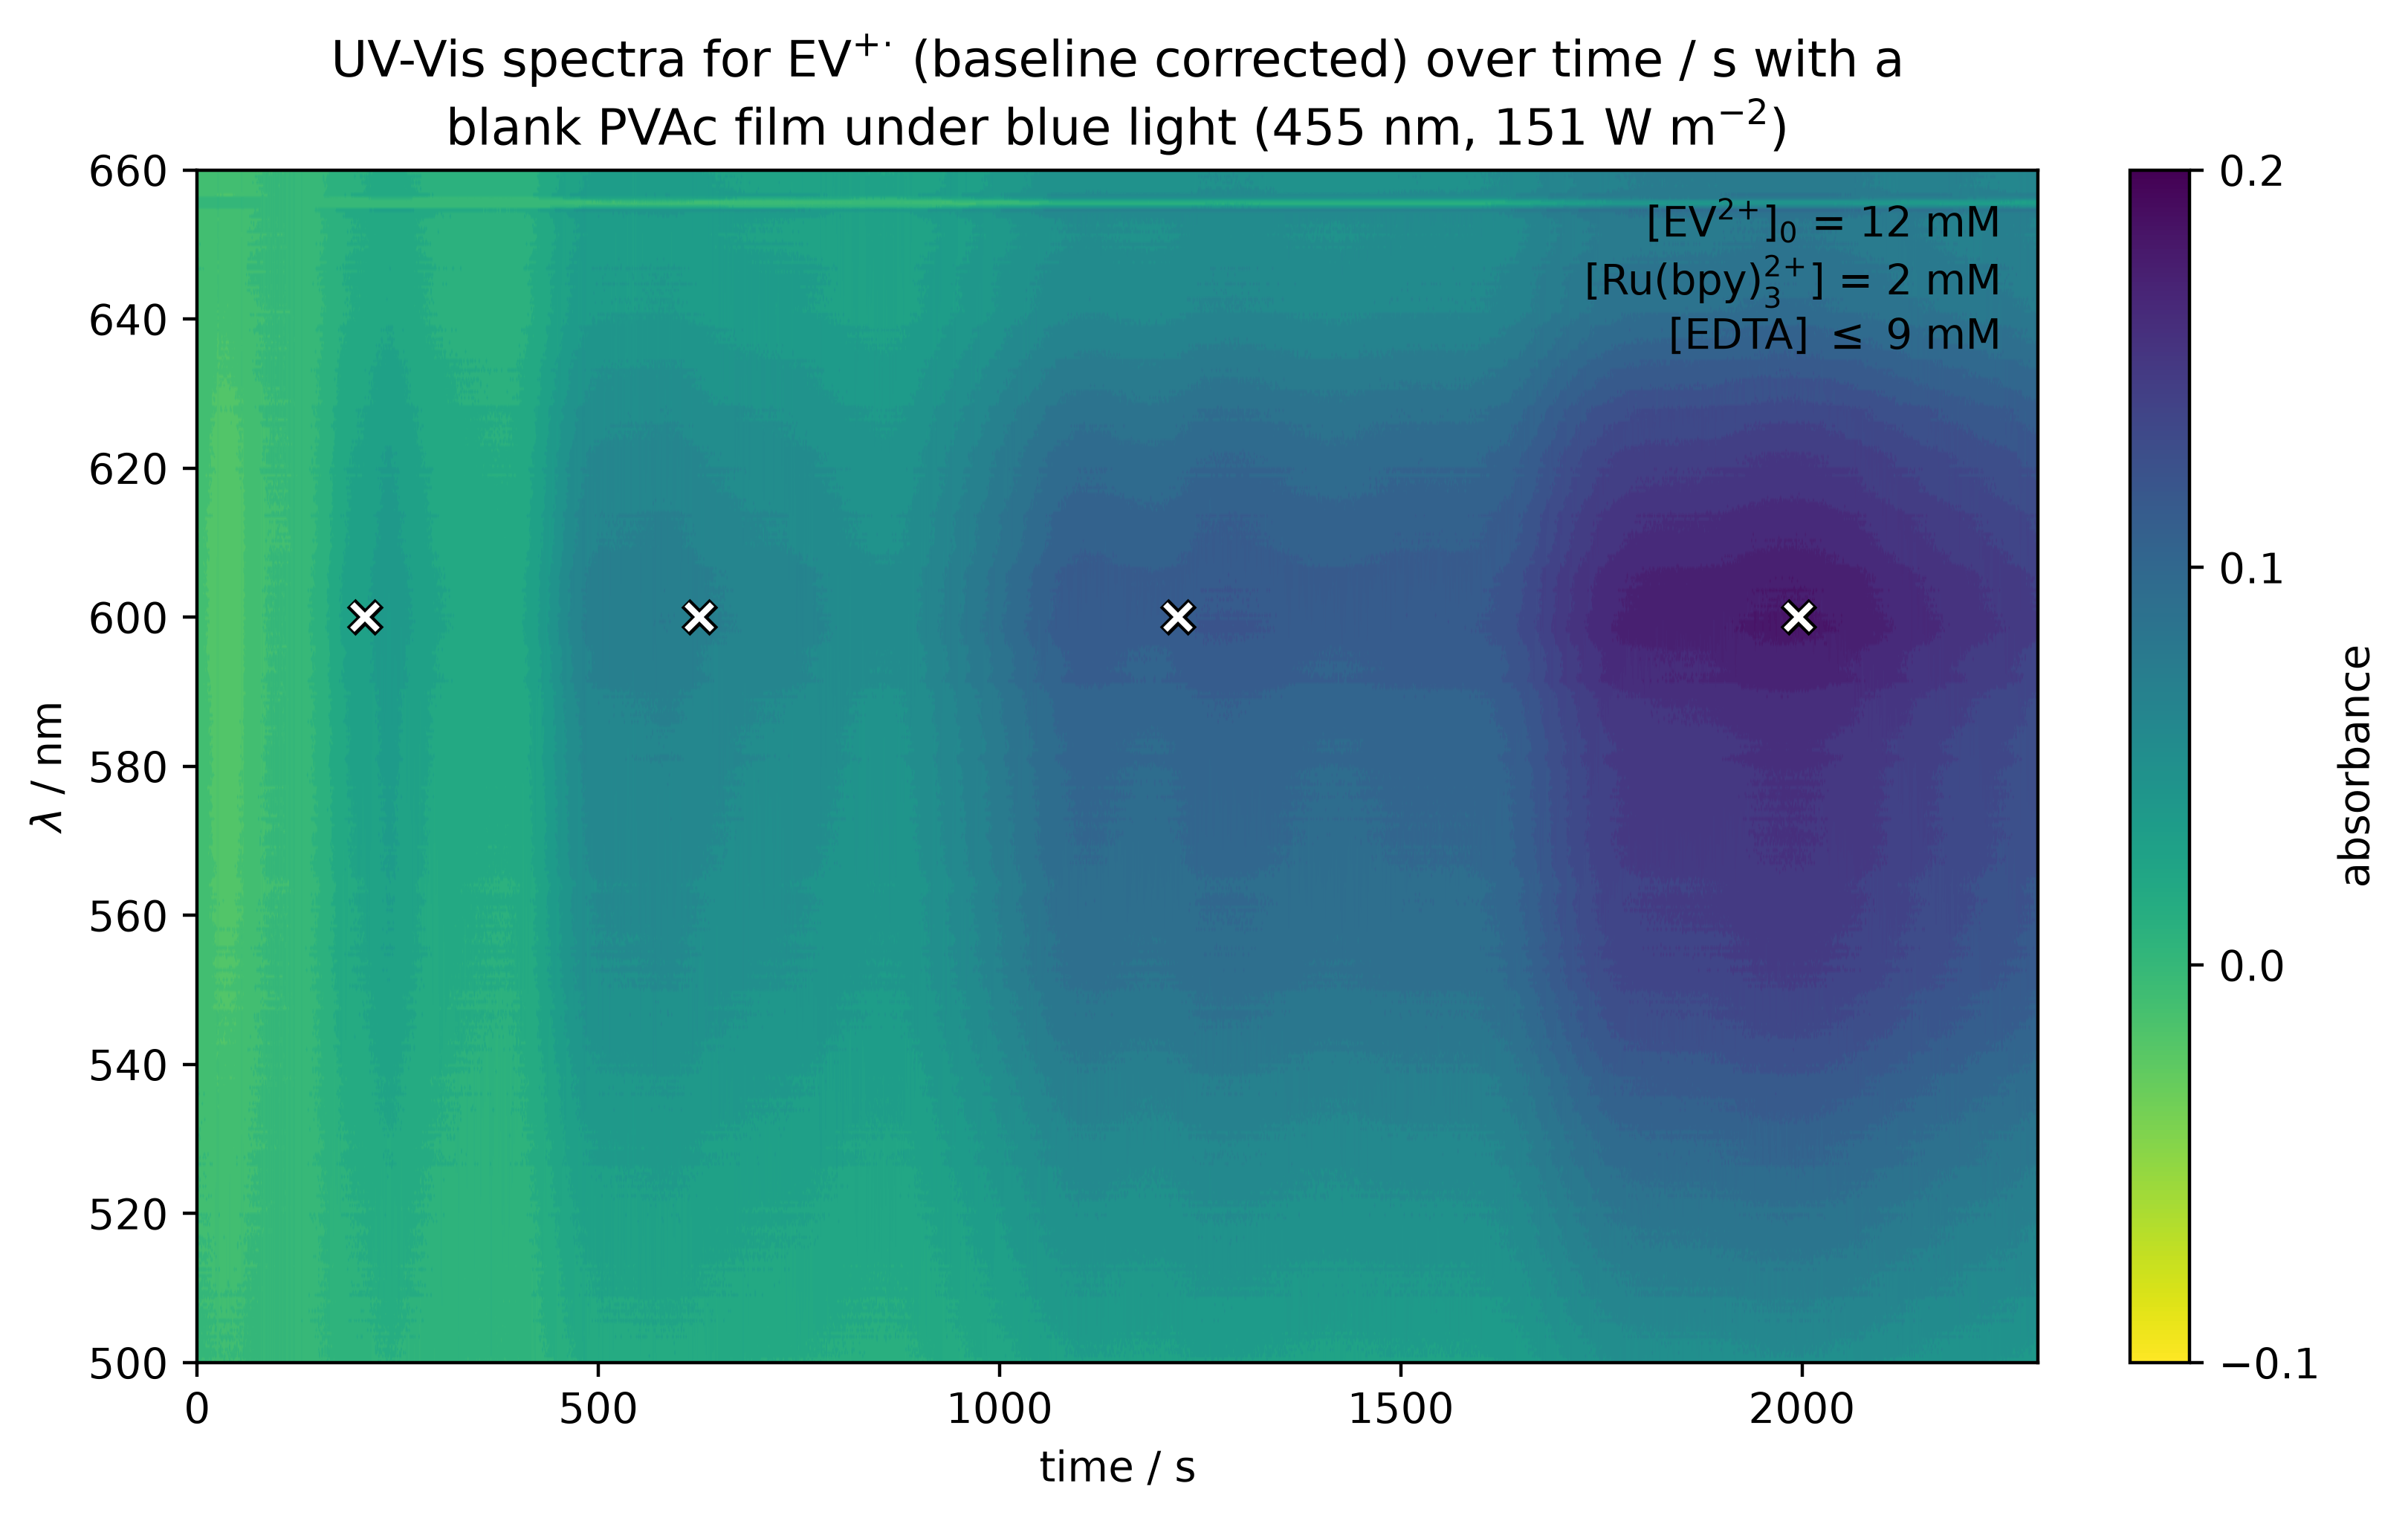

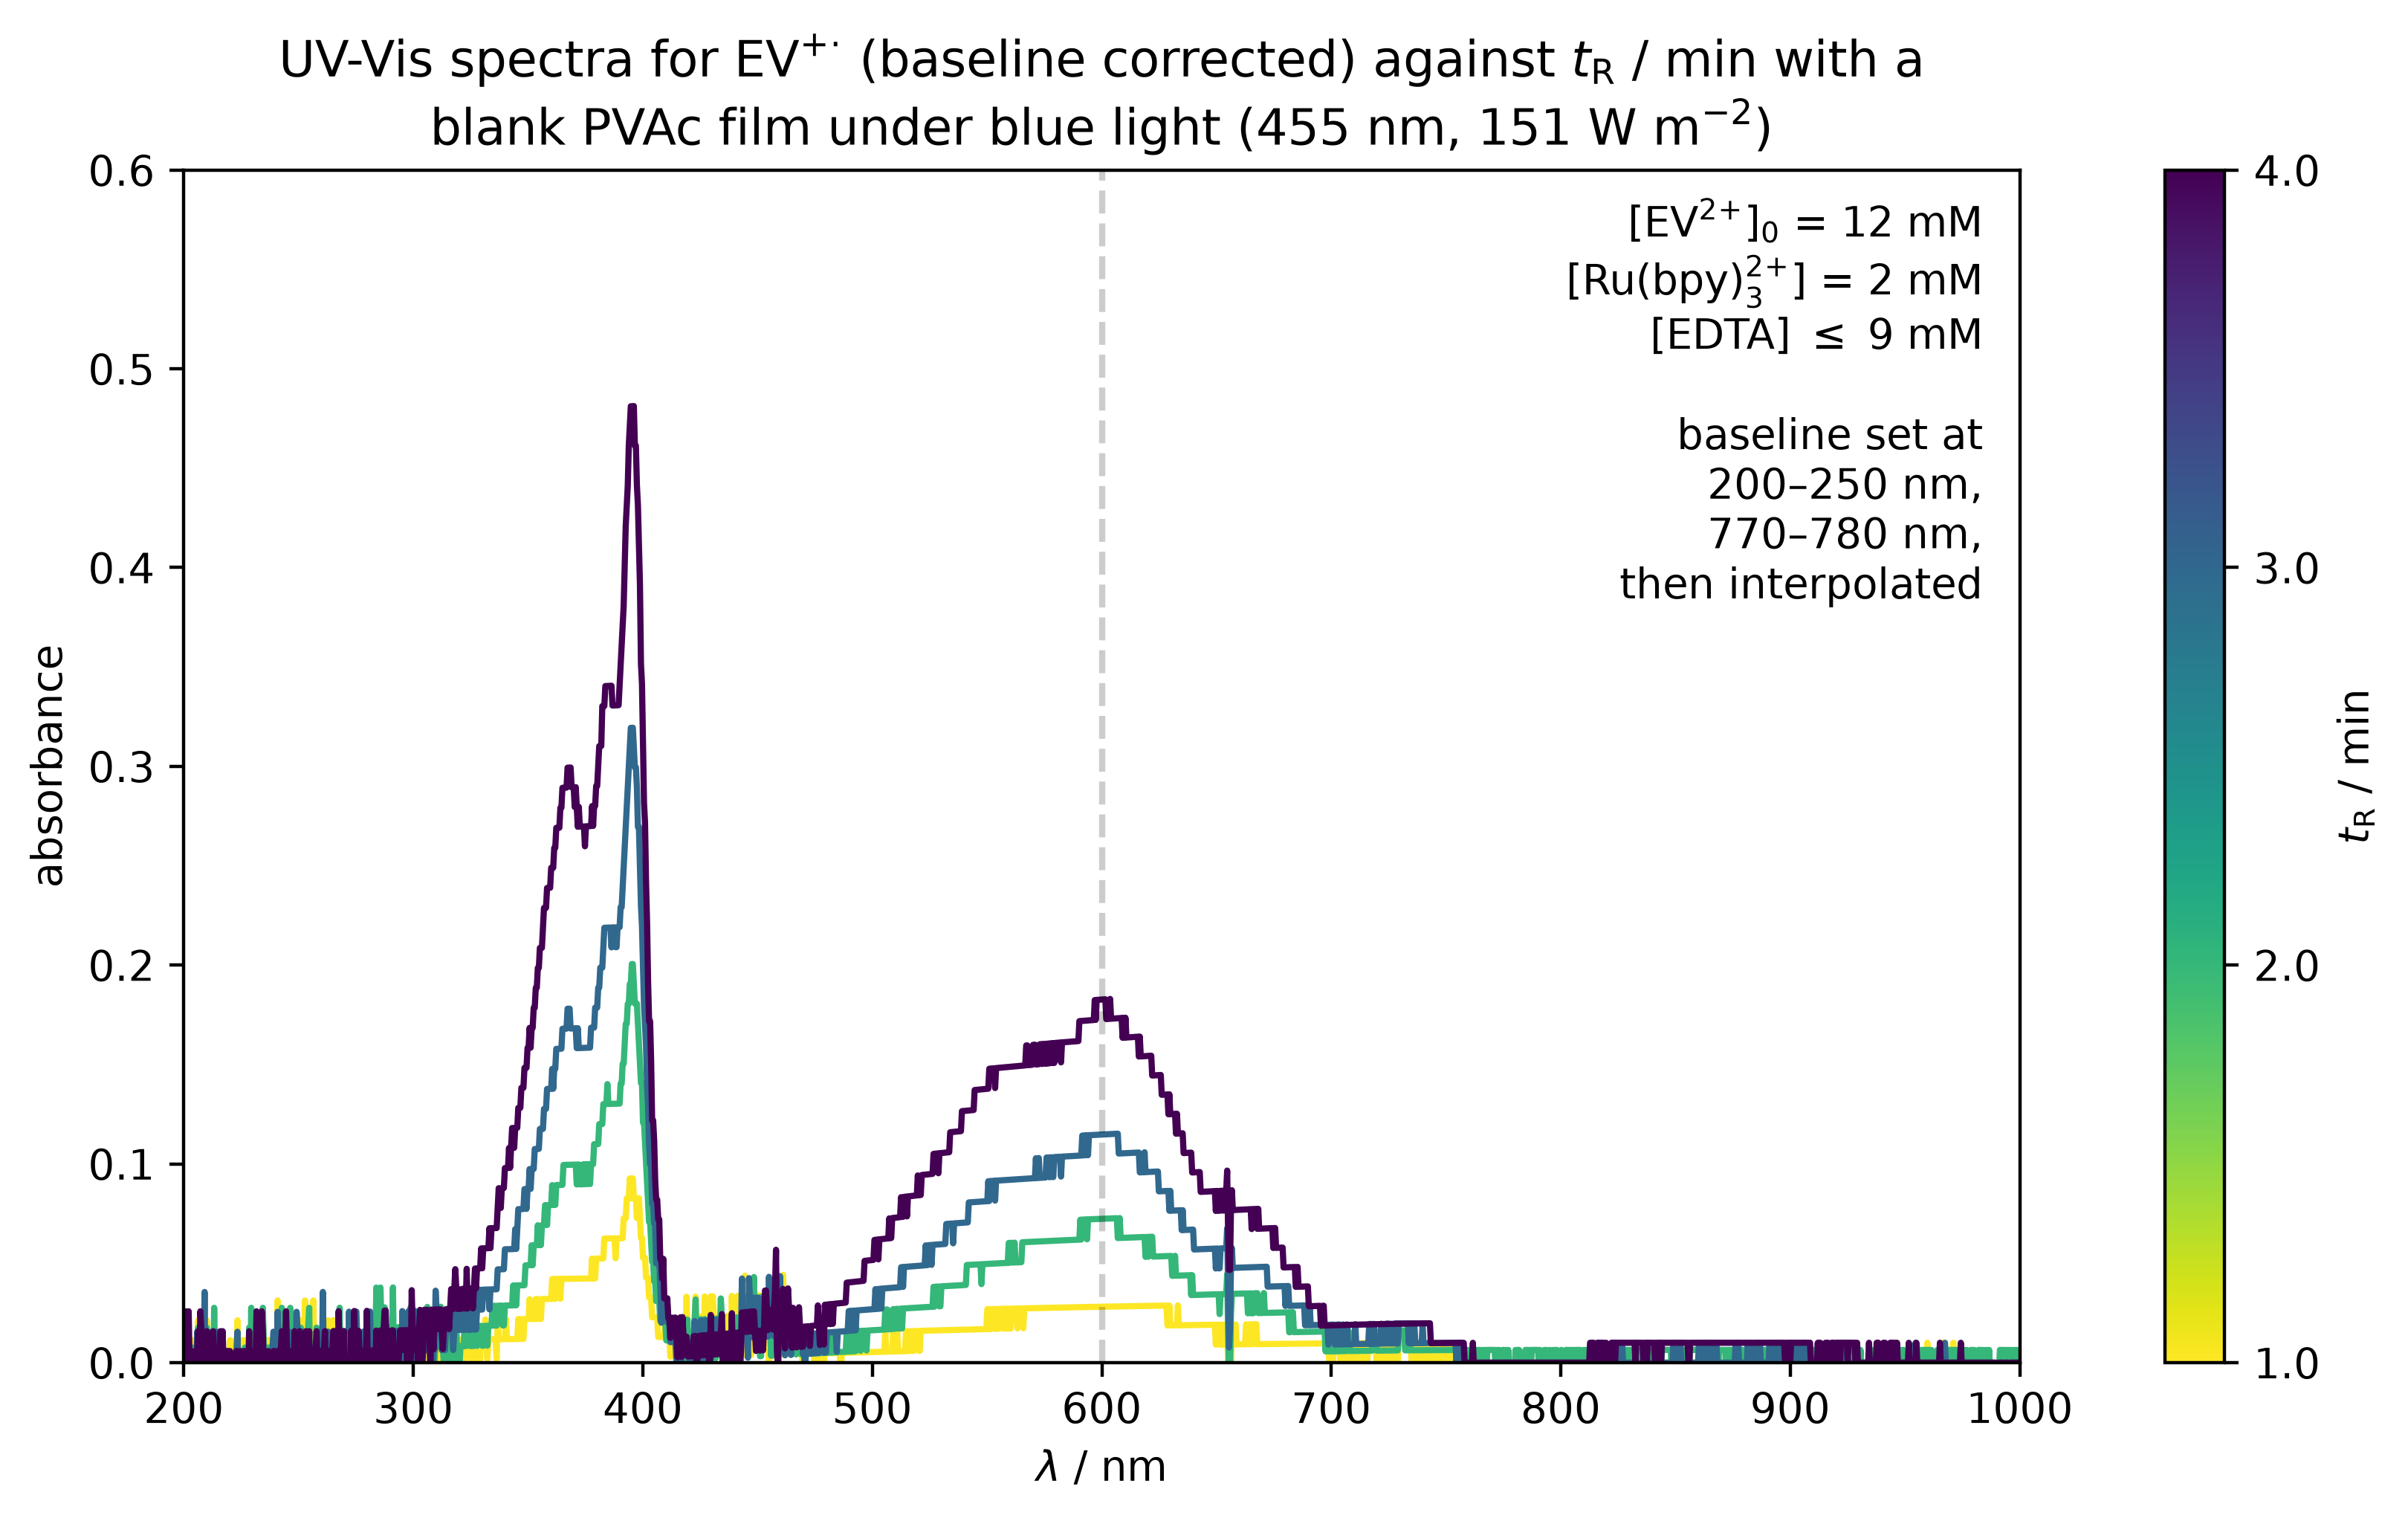

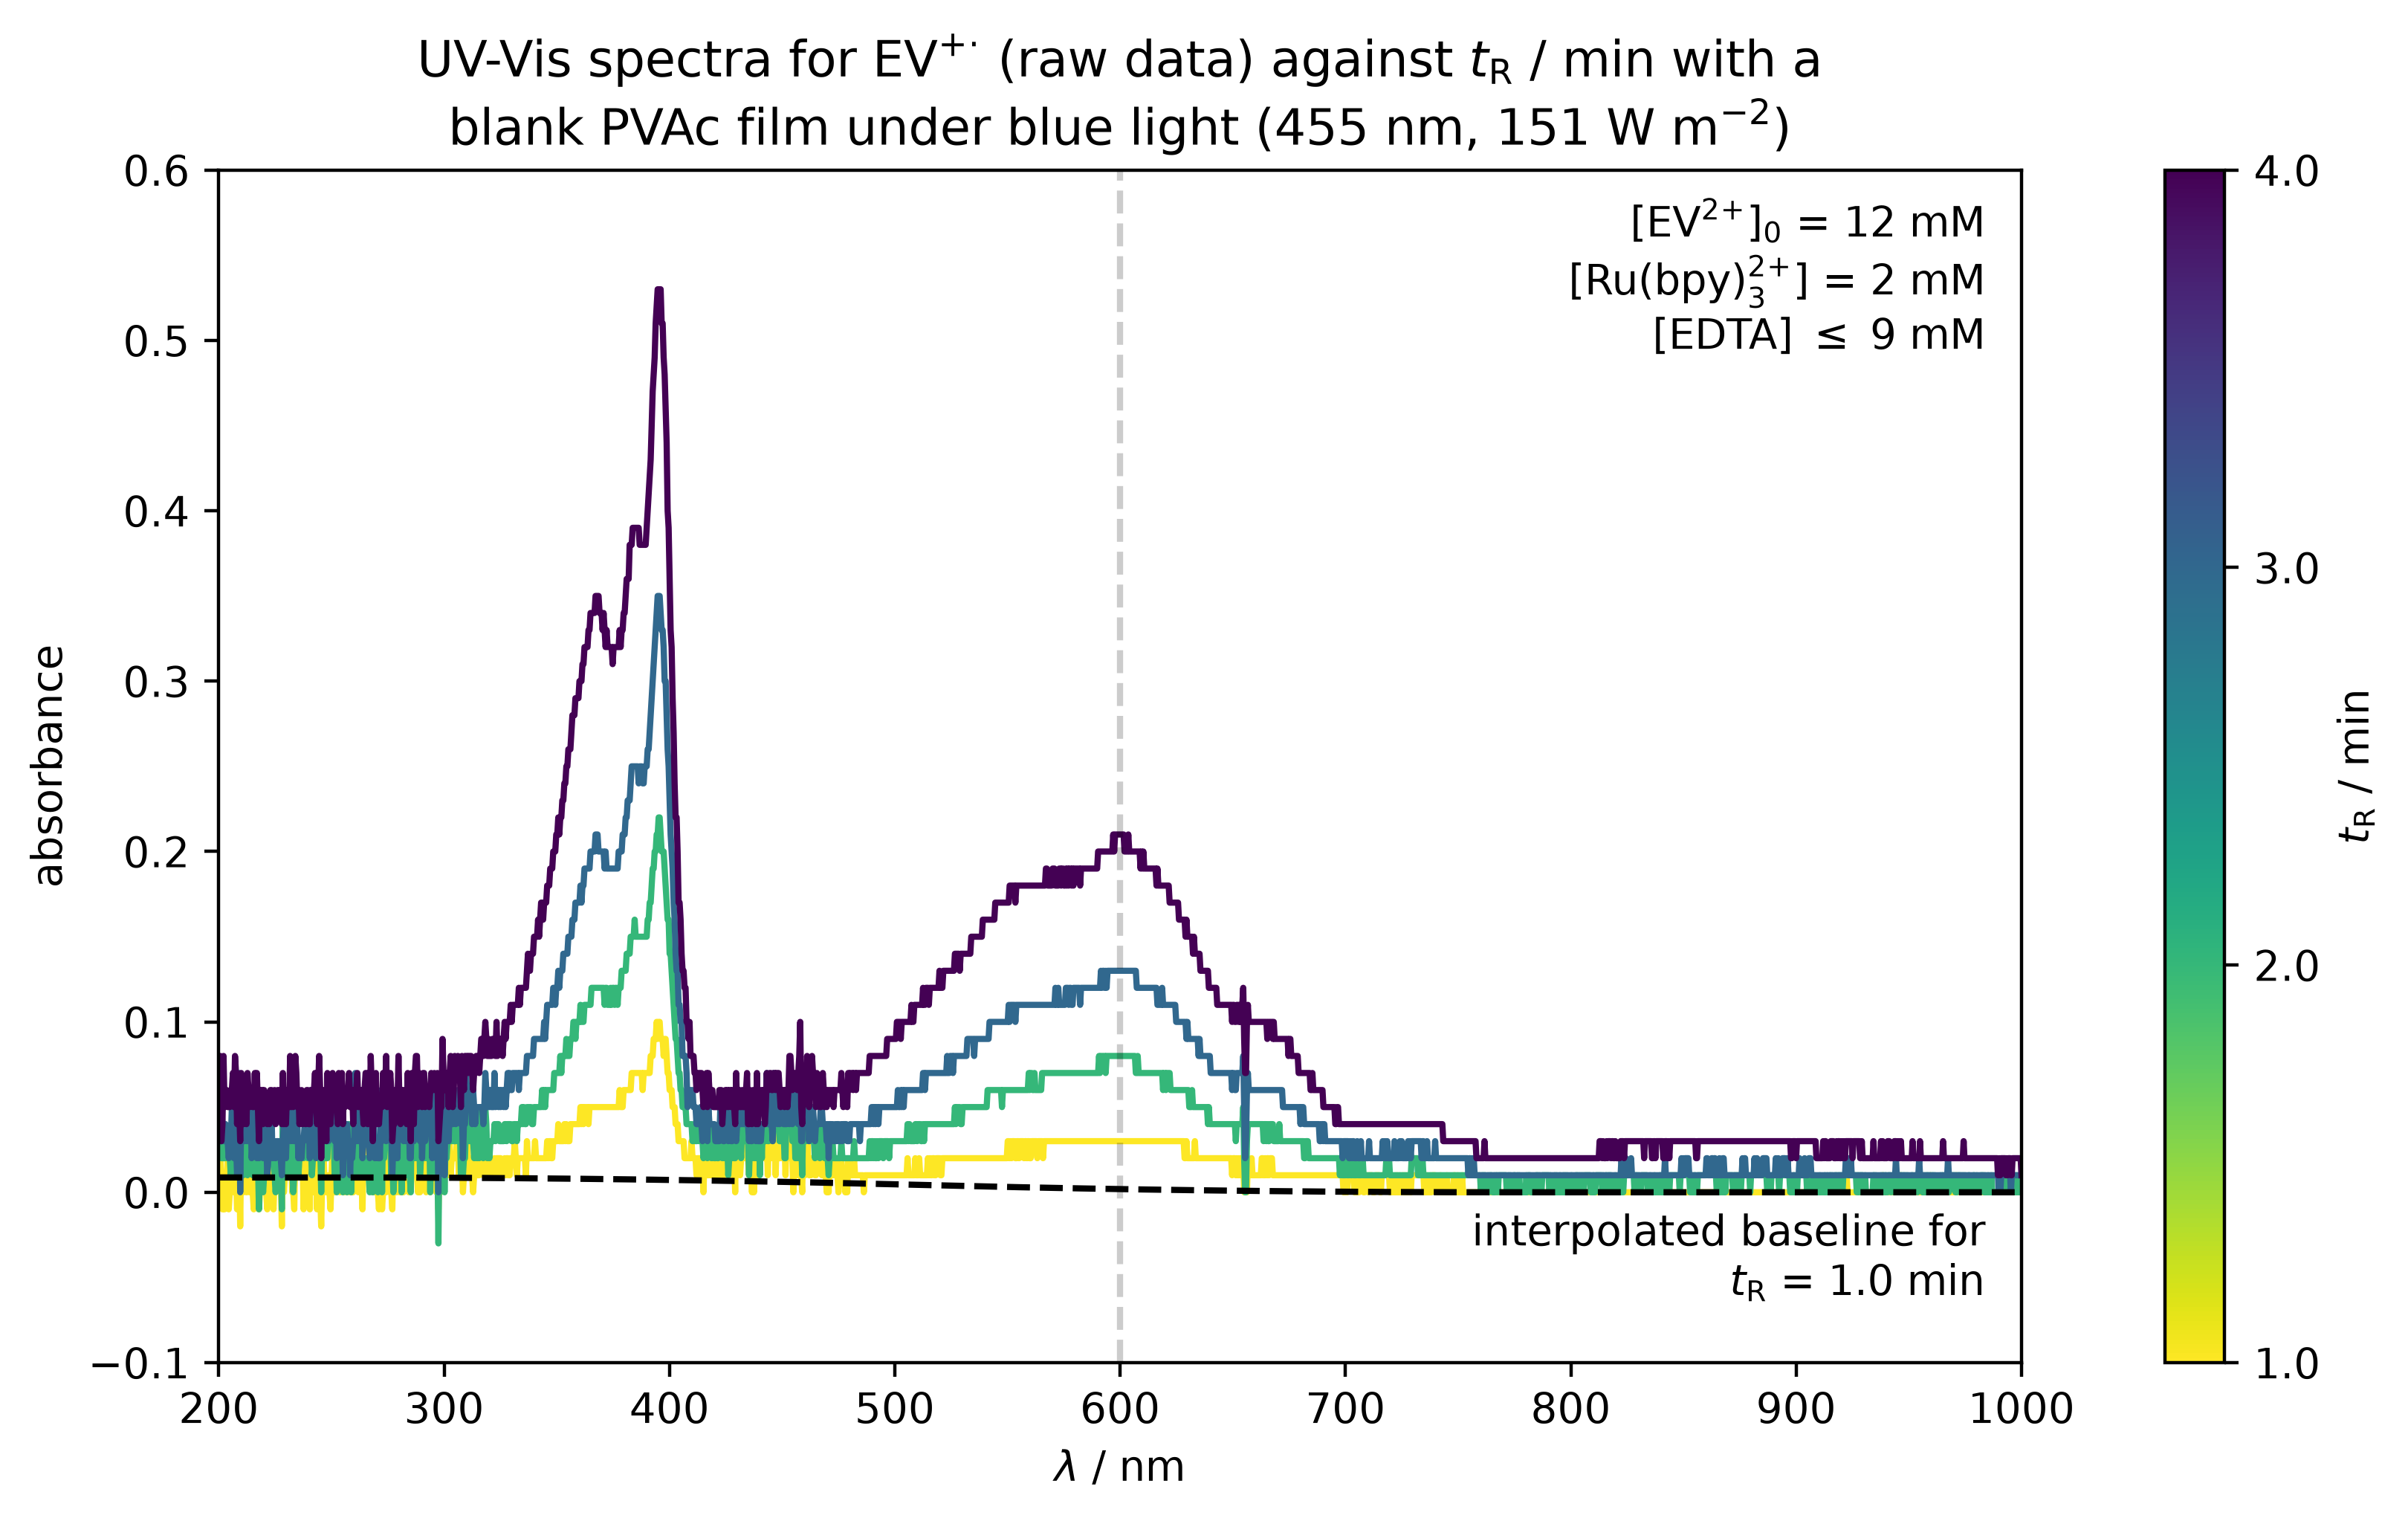

In [1]:
from lsmr_photocatalysis import ContinuousFlow, FLOW_PARAMS, X
import numpy as np

"""
Continuous flow with reaction/LED/film and UV-Vis at opposite ends of a single 250 ul reactor chamber.
Flow rate changes according to flow scheme at different time points to change residence time tR.
Blue 455 nm irradiation at 10.7 mW.

V([Ru(bpy)3]2+, 12.5 mM, pH 6 buffer) = 400 ul (2 mM)
V(EV2+, 25 mM, pH 6 buffer) = 1200 ul (12 mM)
V(EDTA, <25 mM saturated, pH 6 buffer) = 900 ul (<9 mM)
"""

data = '260724_Rubpy_EV_EDTA_Blank_Blue_Flow' # data folder name

tRs = np.arange(60, 4*60+1, 60) # residence times/s for 1-4 min in 1 min intervals
points = ContinuousFlow.recpoints(tRs, *FLOW_PARAMS['250ul']) # time/s points to record absorbances
start = "11-57-00-000" # recorded start time

c0 = 12e-3 # initial EV2+ concentration
details = f'{X['RU']} = 2 mM\n[EDTA] $\\leq$ 9 mM' # concentrations of other reagents

x = 'EVrubpy'
film = 'blank PVAc'
light = 'blue'
wavelength = 455e-9 # m
power = 10.7e-3 # W

expt = ContinuousFlow(data, tRs, points, start, c0, details, x, film, light, wavelength, power)
expt.concvstimeplot()
expt.concvstimeplot(ln=True)
expt.detectorconcplot()
expt.detectorspectrumplot()
expt.spectrumvstimeplot()